In [1]:
from Betts_cluster import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_rect_k_path(nx, ny):
    k_path = []
    
    k_x = [ 2*x/nx for x in range(int(nx/2)+1) ]
    for kx in k_x:
        k_path.append( np.array( [kx, 0] ) )
        
    k_y = [ 2*y/ny for y in range(1, int(ny/2)+1) ]
    
    for ky in k_y:
        k_path.append( np.array( [1, ky] ) )
        
    if nx == ny:
        for ky in (k_y[:-1]).__reversed__():
            k_path.append( np.array( [ky, ky] ) )
    
    return k_path

def get_cluster_k_path(key):
    clust = Cluster(key=key)
    _, k_path = clust.get_k_space()
    return k_path

In [3]:
supercells = [
    '4x4', '18A', '6x4', '4x6', '24A', '32A'
    #'18A', '6x4', '4x6', '24A', '32A'
]

k_paths = {}

for sc in supercells:
    if sc.__contains__('x'):
        k_paths[sc] = get_rect_k_path(int(sc[0]), int(sc[-1]))
    else:
        k_paths[sc] = get_cluster_k_path(sc)

In [4]:
def get_progress_along_path(k_point):
    kx, ky = k_point
    
    if ky == 0:
        return kx
    elif kx == 1.:
        return ky + 1
    elif kx == ky:
        return 2 + np.sqrt(2) * (1. - kx)

In [5]:
def plot_points_from_key_and_vars(key : str, dir = '+-', delta = 1., lamb = 1., eta = 1., to_diameter = True, marker_size = 30., c='gray', alpha = .5, ylim=6):
    try:
        p_s = np.loadtxt(fr'data/d={delta}_l={lamb}_e={eta}/{key}_S_{dir}_mag.txt')
        p_x = np.loadtxt(fr'data/d={delta}_l={lamb}_e={eta}/{key}_S_{dir}_en.txt')
    except:
        if eta == 1.:
            p_s = np.loadtxt(fr'data/d={delta}_l={lamb}/{key}_S_{dir}_mag.txt')
            p_x = np.loadtxt(fr'data/d={delta}_l={lamb}/{key}_S_{dir}_en.txt')
        else:
            pass
    
    sizes = np.zeros( ( p_s.shape[0], p_s.shape[1] + 1 ) )
    sizes[:, :-1] = p_s
    sizes[:, -1] = p_s[:, 0]
    
    energy = np.zeros( ( p_x.shape[0], p_x.shape[1] + 1 ) )
    energy[:, :-1] = p_x
    energy[:, -1] = p_x[:, 0]
    
    sizes = sizes*marker_size

    try:
        if int(key[:2]) == 32:
            sizes *= 15
    except:
        pass

    k_points = np.array(k_paths[key].copy())
    k_path = np.zeros((k_points.shape[0] + 1, k_points.shape[1]))
    k_path[-1, :] = np.array([0, 0])
    k_path[:-1, :] = k_points
    
    if to_diameter:
        sizes = sizes**2
    
    from fractions import Fraction
    
    # ---- Step 1: Build cumulative "distance" along the path ----
    dist = [] #[0.0]
        
    #for i in range(1, len(k_points)):
    #    dk = np.linalg.norm(np.array(k_points[i]) - np.array(k_points[i-1]))
    #    
    #    dist.append(dist[-1] + dk)
    
    for k in k_path[:-1, :]:
        dist.append(get_progress_along_path(k))
    dist.append(2+np.sqrt(2))
    dist = np.array(dist)

    # ---- Helper function to format fractions of π ----
    def format_pi_fraction(value):
        frac = Fraction(value).limit_denominator(12)  # limit denominator (adjust if needed)
        if frac == 0:
            return "0"
        elif frac == 1:
            return r"$\pi$"
        else:
            return fr"$\frac{{{frac.numerator}}}{{{frac.denominator}}}\pi$"

    # ---- Step 2: Define special labels for high symmetry points ----
    labels = []
    tick_positions = []

    for d, (kx, ky) in zip(dist, k_points):
        if (kx, ky) == (0.0, 0.0):
            labels.append(r'$\Gamma$')
        elif (kx, ky) == (1.0, 0.0):
            labels.append(r"$X$")
        elif (kx, ky) == (1.0, 1.0):
            labels.append(r"$M$")
        else:
            kx_label = format_pi_fraction(kx)
            ky_label = format_pi_fraction(ky)
            labels.append(rf"({kx_label}, {ky_label})")
        tick_positions.append(d)


    for ii in range(sizes.shape[1]):
        size_scaled_en = [en if s > 1e-4*marker_size else 99 for en, s in zip(energy[:, ii], sizes[:, ii])]
        min_e = np.min(size_scaled_en)

        for d, en, s in zip([dist[ii]]*len(energy[:, ii]), energy[:, ii], sizes[:, ii]):
            plt.scatter( d, en, s, c=c, alpha=alpha, marker = '_' if np.abs(en-min_e) > .25 else 'x')
        
    plt.ylim([0, ylim])
    
    return np.min(energy)

In [6]:
def plot_LSW(delta, c = 'black', ls = '-'):
    x_range = np.arange( 0, 2.00001, 0.001 )
    
    gamma_k = ( np.cos(np.pi * np.clip(x_range, 0., 1.)) + np.cos(np.pi * (np.clip(x_range, 1., 2.)-1.)) )/2
    y = 2. * np.sqrt(delta**2 - np.square(gamma_k))
    
    plt.plot( x_range, y, c=c, ls = ls, lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True)
    
    gamma_k = np.cos(np.pi * k_range)
    y = 2. * np.sqrt(delta**2 - np.square(gamma_k))

    plt.plot( x_range, y, c=c, ls=ls, lw = 1. )

def plot_JW_fermions(delta, lamb = 0., n0 = 0.0616, t = -0.002):

    x_range = np.arange( 0, 2.00001, 0.001 )
    
    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)
    
    delta_k = ( np.sin(kx)**2 + np.sin(ky)**2 )/4
    y = 2. * np.sqrt((delta * (1 - 2 * lamb * n0))**2 + delta_k * (1 + t * lamb * delta)**2)
    
    plt.plot( x_range, y, 'black', lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True)
    
    delta_k = np.sin(np.pi * k_range)**2/2
    y = 2. * np.sqrt((delta * (1 - 2 * lamb * n0))**2 + delta_k * (1 + t * lamb * delta)**2)

    plt.plot( x_range, y, 'black', lw = 1. )


def plot_ansatz(delta, lamb, alpha, n, c = 'black', ls = '-'):
    x_range = np.arange( 0, 2.00001, 0.001 )
    
    gamma_k = ( np.cos(np.pi * np.clip(x_range, 0., 1.)) + np.cos(np.pi * (np.clip(x_range, 1., 2.)-1.)) )/2
    y = 2. * np.sqrt((delta + alpha - 2 * delta * lamb * n)**2 - np.square(gamma_k))
    #y = 2. * np.sqrt((delta - 4 * delta * (lamb - 1.) * n)**2 - np.square(gamma_k))
    
    plt.plot( x_range, y, c=c, ls = ls, lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k_range = np.linspace(1., 0., len(x_range), endpoint=True)
    
    gamma_k = np.cos(np.pi * k_range)
    y = 2. * np.sqrt((delta + alpha - 2 * delta * lamb * n)**2 - np.square(gamma_k))
    #y = 2. * np.sqrt((delta - 4 * delta * (lamb - 1.) * n)**2 - np.square(gamma_k))

    plt.plot( x_range, y, c=c, ls=ls, lw = 1. )

def plot_hcb_b_mf(ak, b, eta = 1., c = 'green', ls = '-'):
    x_range = np.arange( 0, 2.00001, 0.001 )
    kx = np.pi * np.clip(x_range, 0., 1.)
    ky = np.pi * (np.clip(x_range, 1., 2.)-1.)
    
    gamma2_k = ( np.cos(kx)**2 + np.cos(ky)**2 + 2 * np.cos(kx) * np.cos(ky) * np.cos(np.pi/2 * (1-eta)) )/4
    y = np.sqrt(ak**2 - b**2 * gamma2_k)
    
    plt.plot( x_range, y, c=c, ls = ls, lw = 1. )
    
    x_range = np.linspace( 2, 2+np.sqrt(2), len(x_range), endpoint=True )
    k = np.linspace(np.pi, 0., len(x_range), endpoint=True)
    
    gamma2_k = ( 2*np.cos(k)**2 + 2 * np.cos(k)**2 * np.cos(np.pi/2 * (1-eta)) )/4
    y = np.sqrt(ak**2 - b**2 * gamma2_k)

    plt.plot( x_range, y, c=c, ls=ls, lw = 1. )


In [7]:
colors = {
    '4x4': '#d81159', '18A': '#8f2d56', '6x4': '#218380', '24A' : '#73d2de'
}

colors = {
    '4x4': '#d21f3c', '18A': '#782a4f', '6x4': '#1d3461', '4x6': '#1f487e', '24A' : '#247ba0', '32A' : '#5a189a'
}

from matplotlib.lines import Line2D

def plot_all_for_var(dir : str = '+-', delta : float = 1., lamb : float = 1., eta = 1., to_diameter : bool = True,
                     marker_size : float = 30., alpha = .5, ylim=6, show = True, plot_analytics = True):

    keys = colors.keys()
    color = colors.values()
    
    min_en = 999.
    
    legend_elements = []

    # add Gerardo's and Daniel's results
    if eta == 0.:
        try:
            data = np.loadtxt(rf'data/JW_MF_data/Spm_q_w_Delta_{float(delta)}0_lambda_{float(lamb)}0_eta_1.00_h_0.00_Lx_20_Ly_20.txt', skiprows=1)
            points, omega, intensity = data.T

            points[:20] = points[:20]/10
            points[20:] = 2 + (points[20:] - 20)/10*np.sqrt(2)

            plt.scatter(points, omega, s = (intensity*3e3)**2, facecolors = 'w', edgecolors = 'purple')
        except:
            pass

    for key, c in zip(keys, color):
        try:
            new_min_en = plot_points_from_key_and_vars(key, dir, delta, lamb, eta, to_diameter, marker_size, c, alpha, ylim)
            if new_min_en < min_en:
                min_en = new_min_en
            legend_elements.append(Line2D([0], [0], marker='o', color='w', label=key ,markerfacecolor=c, markersize=10, alpha=alpha))
        except:
            #print('No file for key: ' + key)
            pass

    if plot_analytics:
        if lamb == 1. and ((delta > 1 and dir == '+-') or delta == 1.) and eta == 1.:
            plot_LSW(delta)
            legend_elements.append(Line2D([0], [0], color='black', lw=1., ls='-', label='LSW'))
        elif delta >= 1 and eta == 0. and dir == '+-':

            ns_of_delta = {1.0 : 0.0616, 2.0 : 0.0229}
            ts_of_delta = {1.0 : -2e-3, 2.0 : -6e-4}
            plot_JW_fermions(delta, lamb, ns_of_delta[float(delta)], ts_of_delta[float(delta)])

            name = 'free fermions'
            if lamb > 0:
                name += ' + MF'

            legend_elements.append(Line2D([0], [0], color='black', lw=1., ls='-', label=name))
        
        pars_from_mf = {
            (1., 0., 1.): [2.45571, 1.88616],
            (1., 0., 0.): [2.41709, 1.86852],
            (1., 1., 0.): [2.19231, 1.8323],
            (2., 0., 0.): [4.2368, 1.96288],
            (2., 1., 0.): [4.11782, 1.96055],
            (1., 0., 0.25): [2.43207, 1.87527],
            (1., 0., 0.5): [2.44457, 1.88099],
            (1., 0., 0.75): [2.45283, 1.88482],
        }

        try:
            a, b = pars_from_mf[round(delta, 2), round(lamb, 2), round(eta, 2)]
            plot_hcb_b_mf(a, b, eta)
            legend_elements.append(Line2D([0], [0], color='green', lw=1., ls='-', label='sc-MF'))
        except:
            pass
    
    plt.xticks([0, 1., 2., 2.+np.sqrt(2)], [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'], rotation = 0)
    plt.title(rf'$S^{{{dir}}}(q, \omega)$, '
        + rf'$\Delta$ = {delta}'
        + (rf', $\lambda$ = {lamb}' if (delta != 0) else '')
        + (rf', $\eta$ = {eta}' if (delta != 0) else '')
        )
    plt.ylabel(r'$\omega$/J')
    plt.legend(handles = legend_elements, loc=1)
    if show:
        plt.show()

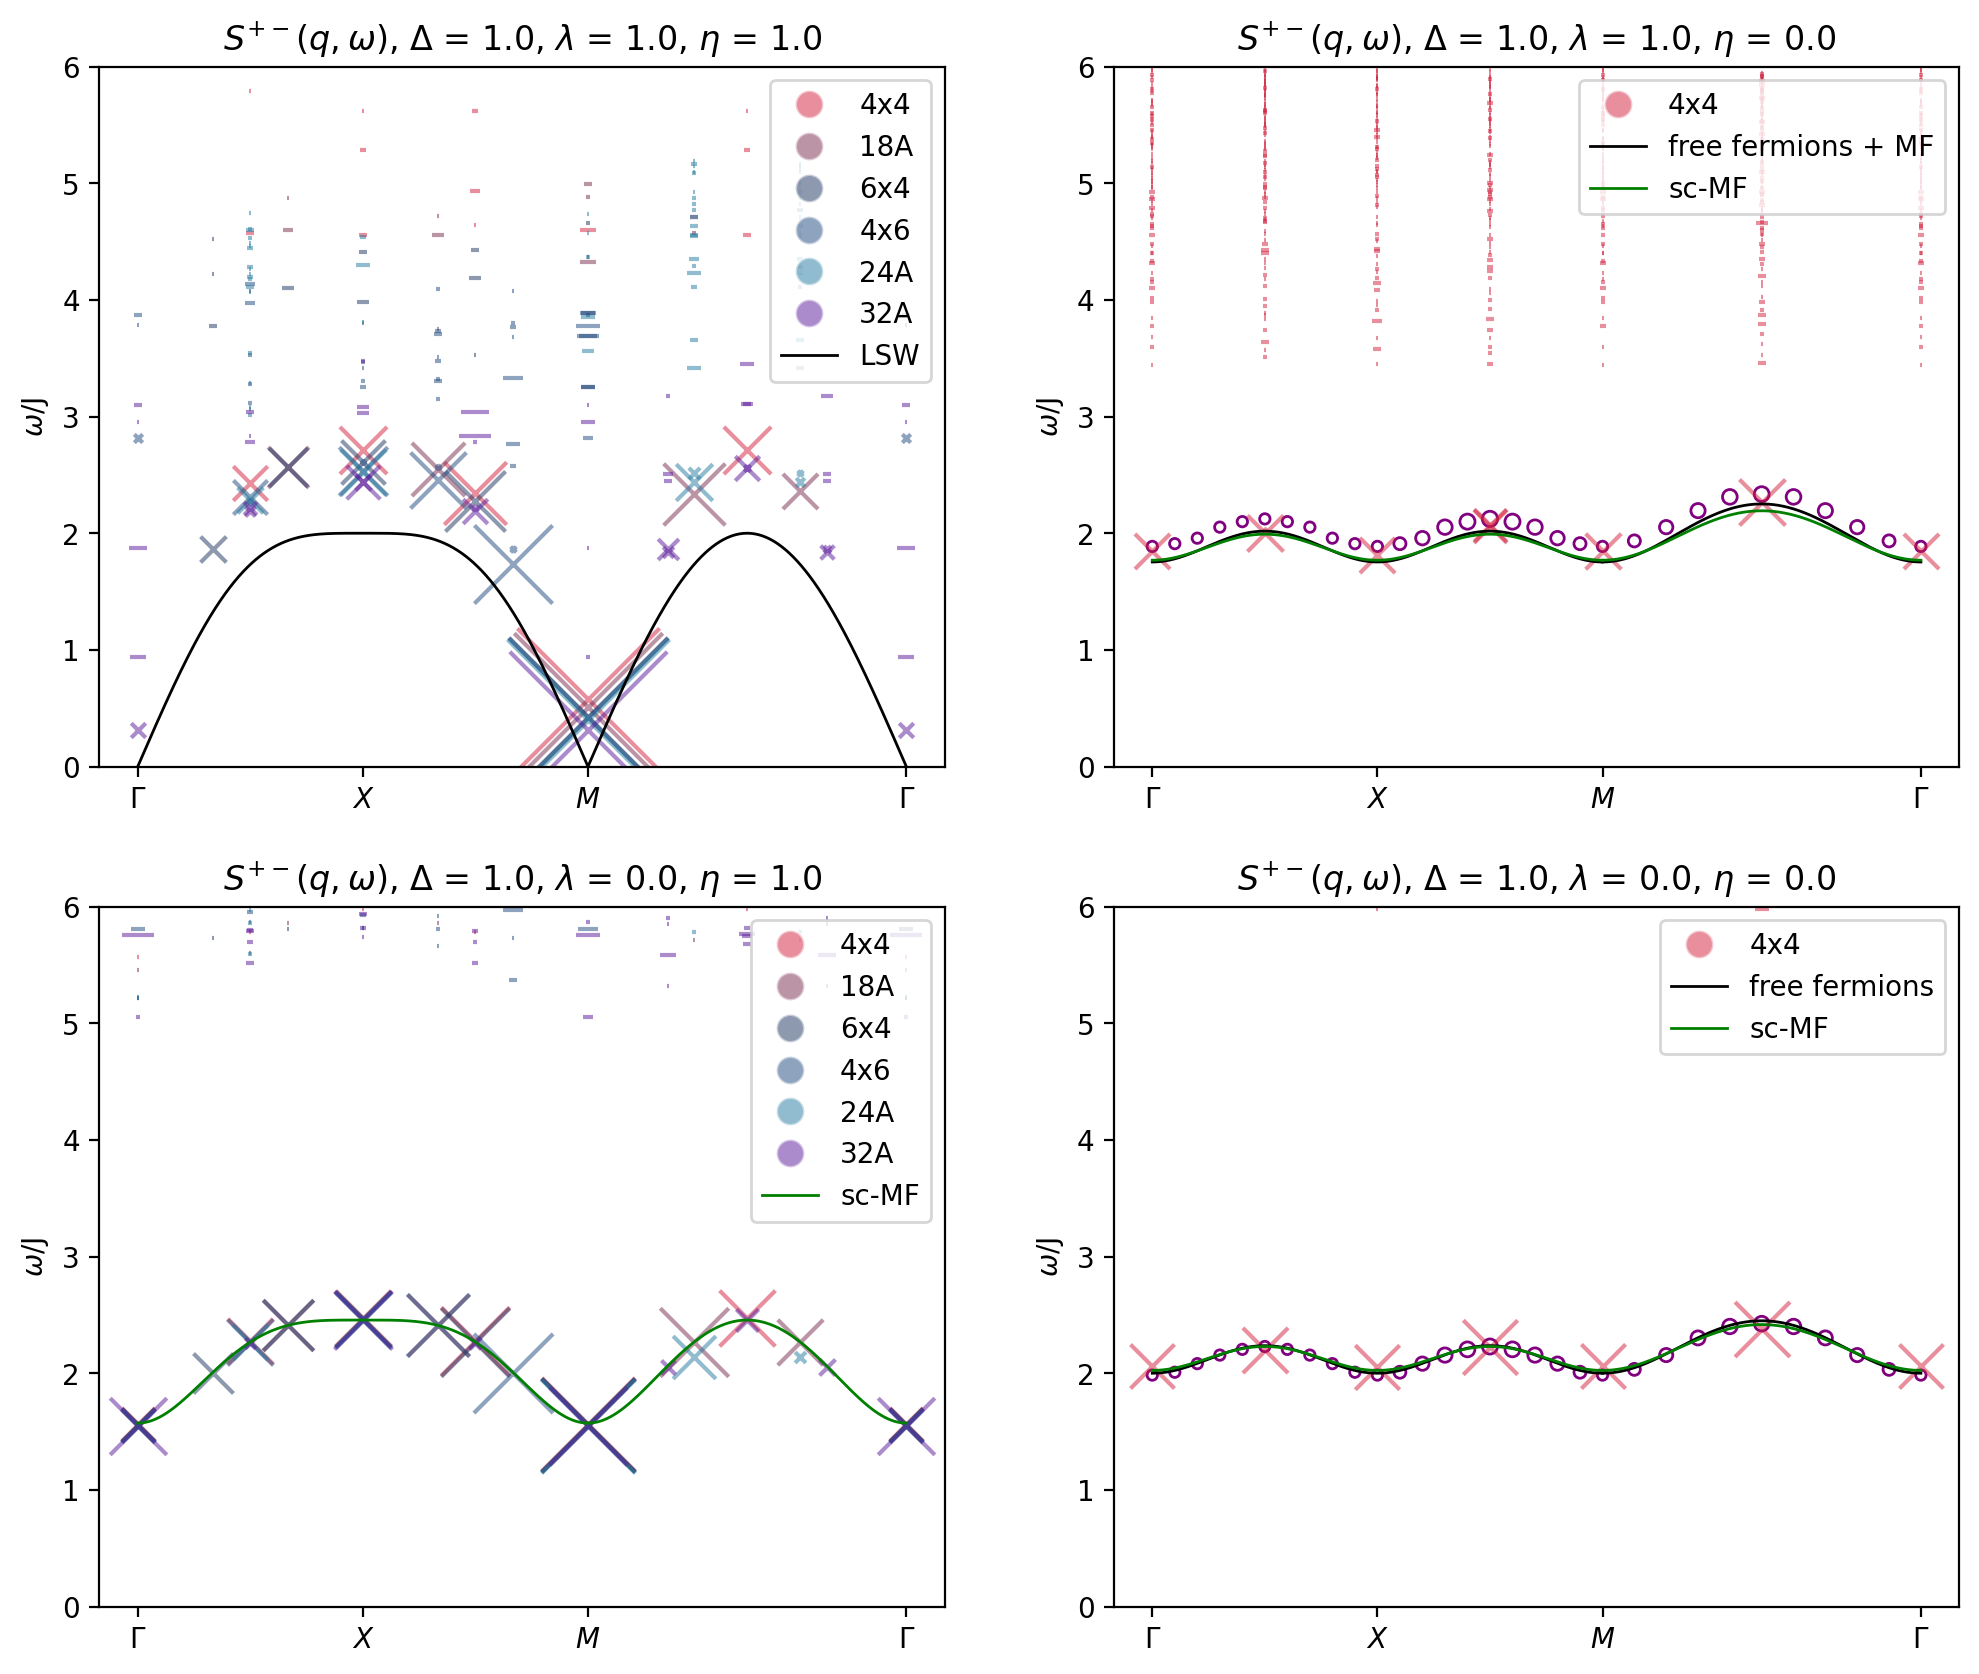

In [8]:
fig = plt.figure(figsize = (12, 10), dpi = 200)
plt.subplot(2, 2, 1)
plot_all_for_var(dir='+-', delta=1., lamb=1., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 2)
plot_all_for_var(dir='+-', delta=1., lamb=1., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 3)
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 4)
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.show()

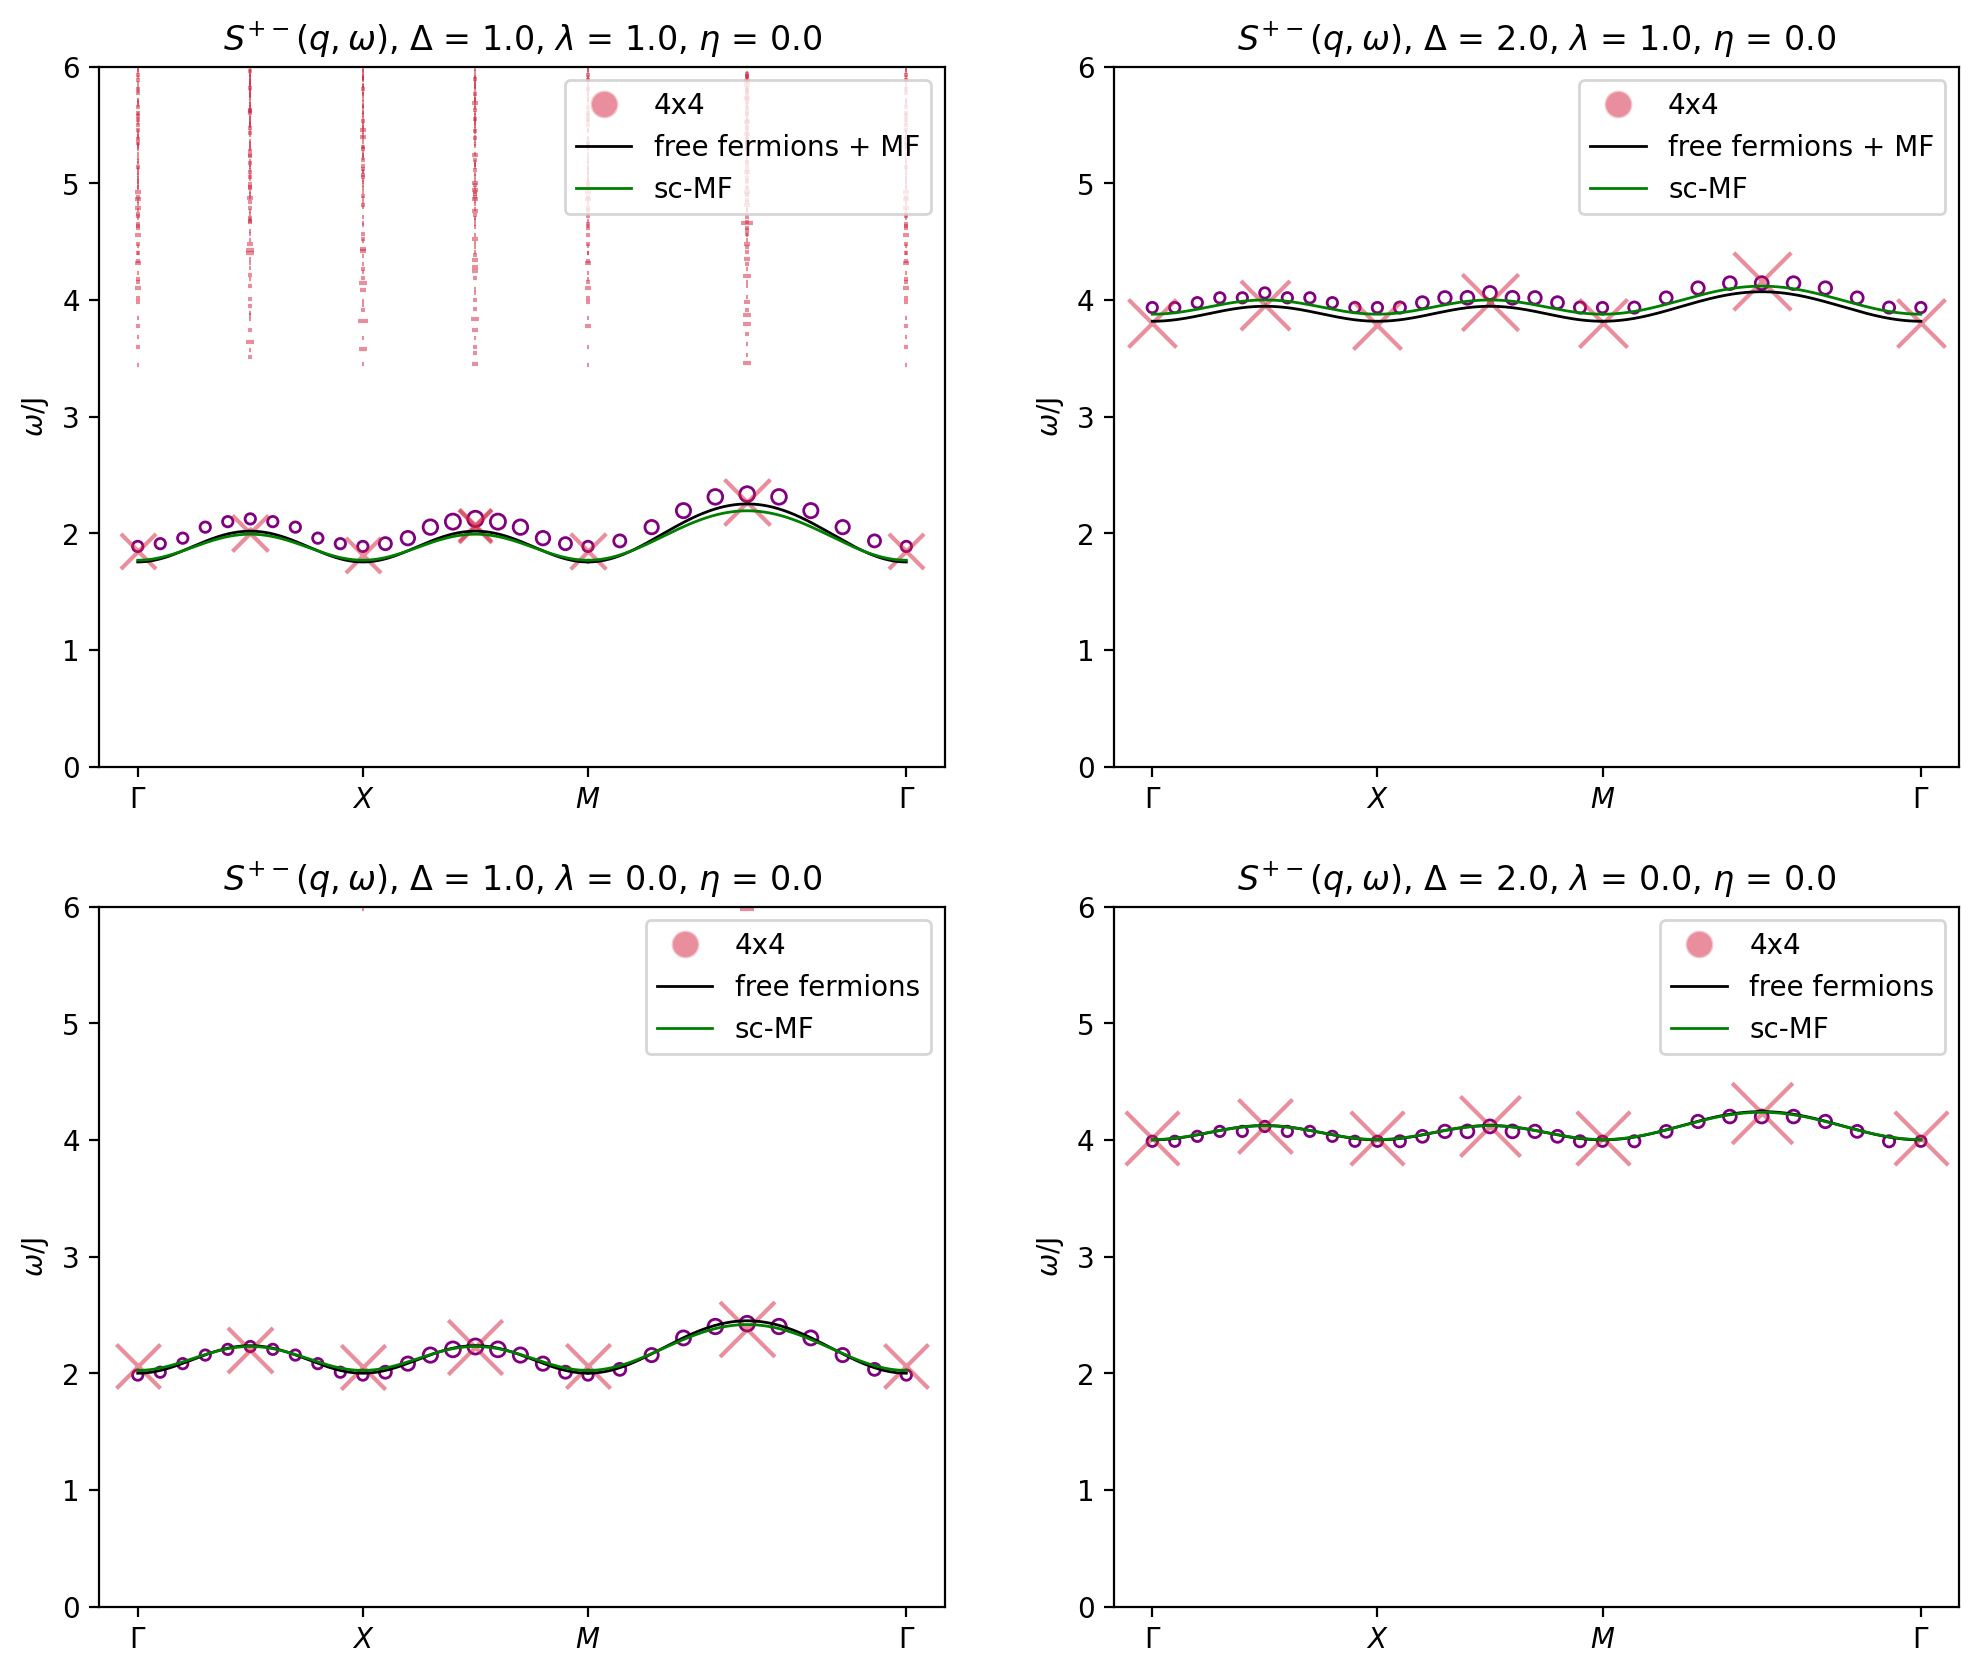

In [9]:
fig = plt.figure(figsize = (12, 10), dpi = 200)
plt.subplot(2, 2, 1)
plot_all_for_var(dir='+-', delta=1., lamb=1., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 2)
plot_all_for_var(dir='+-', delta=2., lamb=1., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 3)
plot_all_for_var(dir='+-', delta=1., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.subplot(2, 2, 4)
plot_all_for_var(dir='+-', delta=2., lamb=0., eta = 0., to_diameter=False, marker_size=900, alpha=.5, show = False)
plt.show()

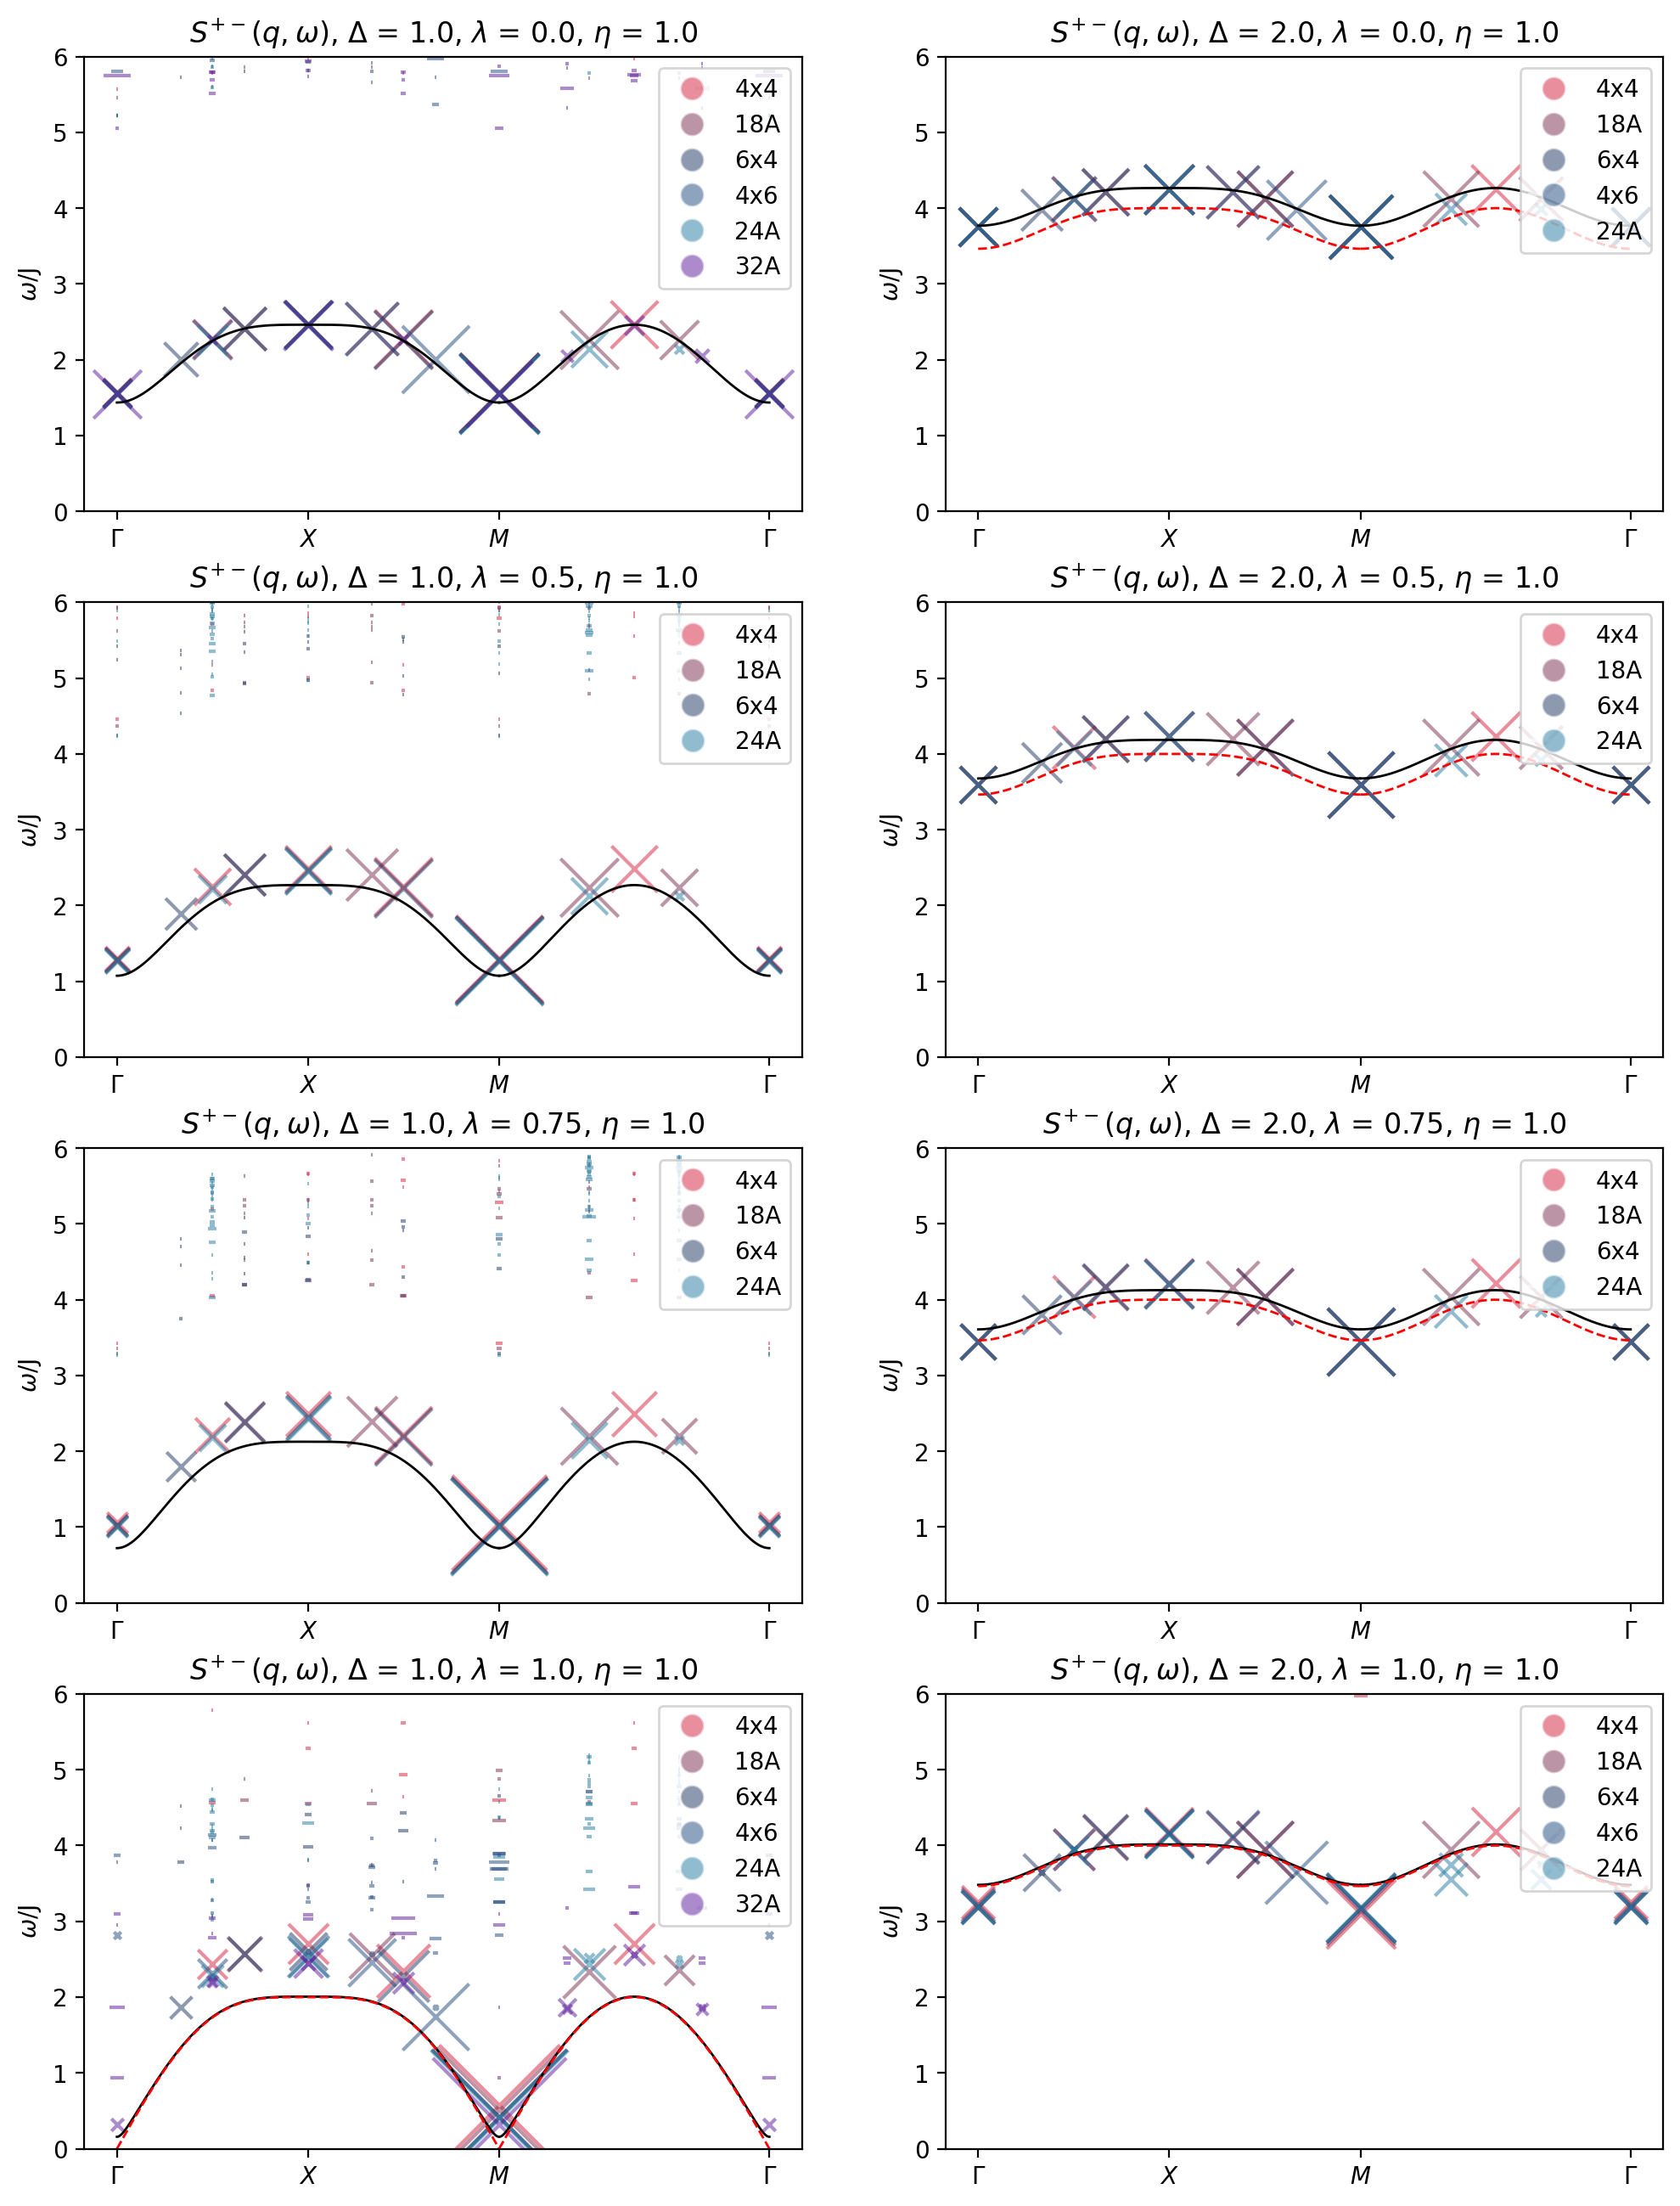

In [10]:
def find_function_lamb(delta = 1., lamb = 0., _alpha = 0., n = .05):
    plot_ansatz(delta, lamb, _alpha, n)
    plot_all_for_var(dir='+-', delta=delta, lamb=lamb, eta = 1., to_diameter=False, marker_size=900, alpha=.5, show = False, plot_analytics=False)

fig = plt.figure(figsize = (12, 16), dpi = 200)
plt.subplot(4, 2, 1)
find_function_lamb(1., 0., 0.46175418/2) #0.03910101867787485
plt.subplot(4, 2, 2)
find_function_lamb(2., 0., 0.53066/4, n = 0.015) #0.009758864997001914
plot_LSW(2., 'red', '--')

plt.subplot(4, 2, 3)
find_function_lamb(1., 0.5, 0.37003794/2) # 0.37003794
plt.subplot(4, 2, 4)
find_function_lamb(2., 0.5, 0.4903863/4, n = 0.015) #0.009758864997001914
plot_LSW(2., 'red', '--')

plt.subplot(4, 2, 5)
find_function_lamb(1., 0.75, 0.27673808/2) # 0.27673808
plt.subplot(4, 2, 6)
find_function_lamb(2., 0.75, 0.43196668/4, n = 0.015) #0.009758864997001914
plot_LSW(2., 'red', '--')

plt.subplot(4, 2, 7)
find_function_lamb(1., 1., 0.20619835/2) # 0.20619835
plot_LSW(1., 'red', '--')
plt.subplot(4, 2, 8)
find_function_lamb(2., 1., 0.2692908/4, n = 0.015) #0.009758864997001914
plot_LSW(2., 'red', '--')
plt.show()

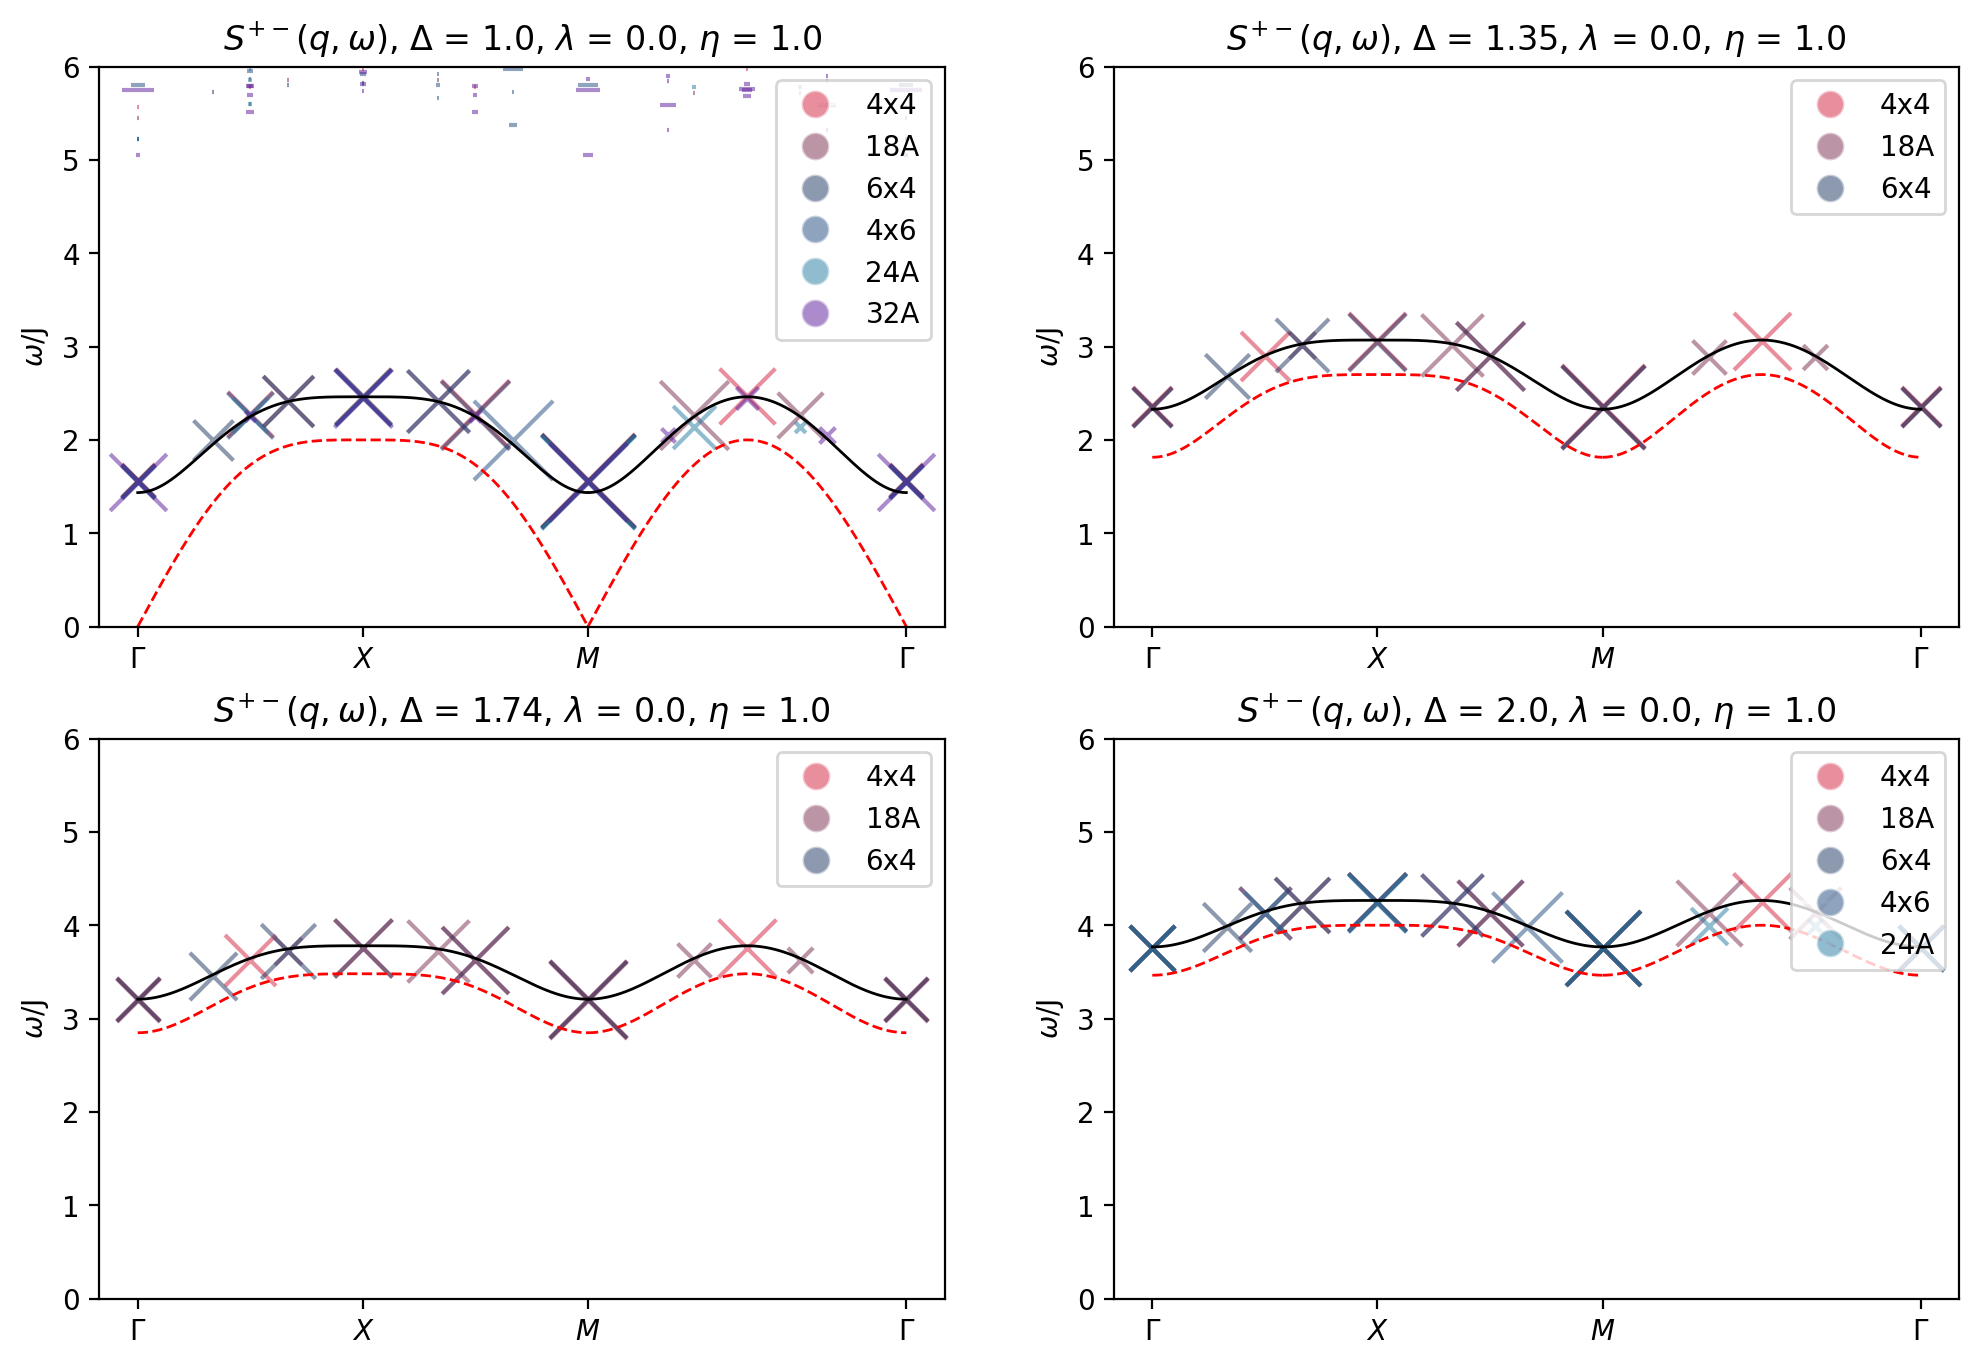

In [11]:
fig = plt.figure(figsize = (12, 8), dpi = 200)

plt.subplot(2, 2, 1)
find_function_lamb(1., 0., 0.46175418/2/1.)
plot_LSW(1., 'red', '--')

plt.subplot(2, 2, 2)
find_function_lamb(1.35, 0., 0.4990152/2/1.35)
plot_LSW(1.35, 'red', '--')

plt.subplot(2, 2, 3)
find_function_lamb(1.74, 0., 0.52161271/(2*1.74))
plot_LSW(1.74, 'red', '--')

plt.subplot(2, 2, 4)
find_function_lamb(2., 0., 0.53066/4) #0.009758864997001914
plot_LSW(2., 'red', '--')

plt.show()

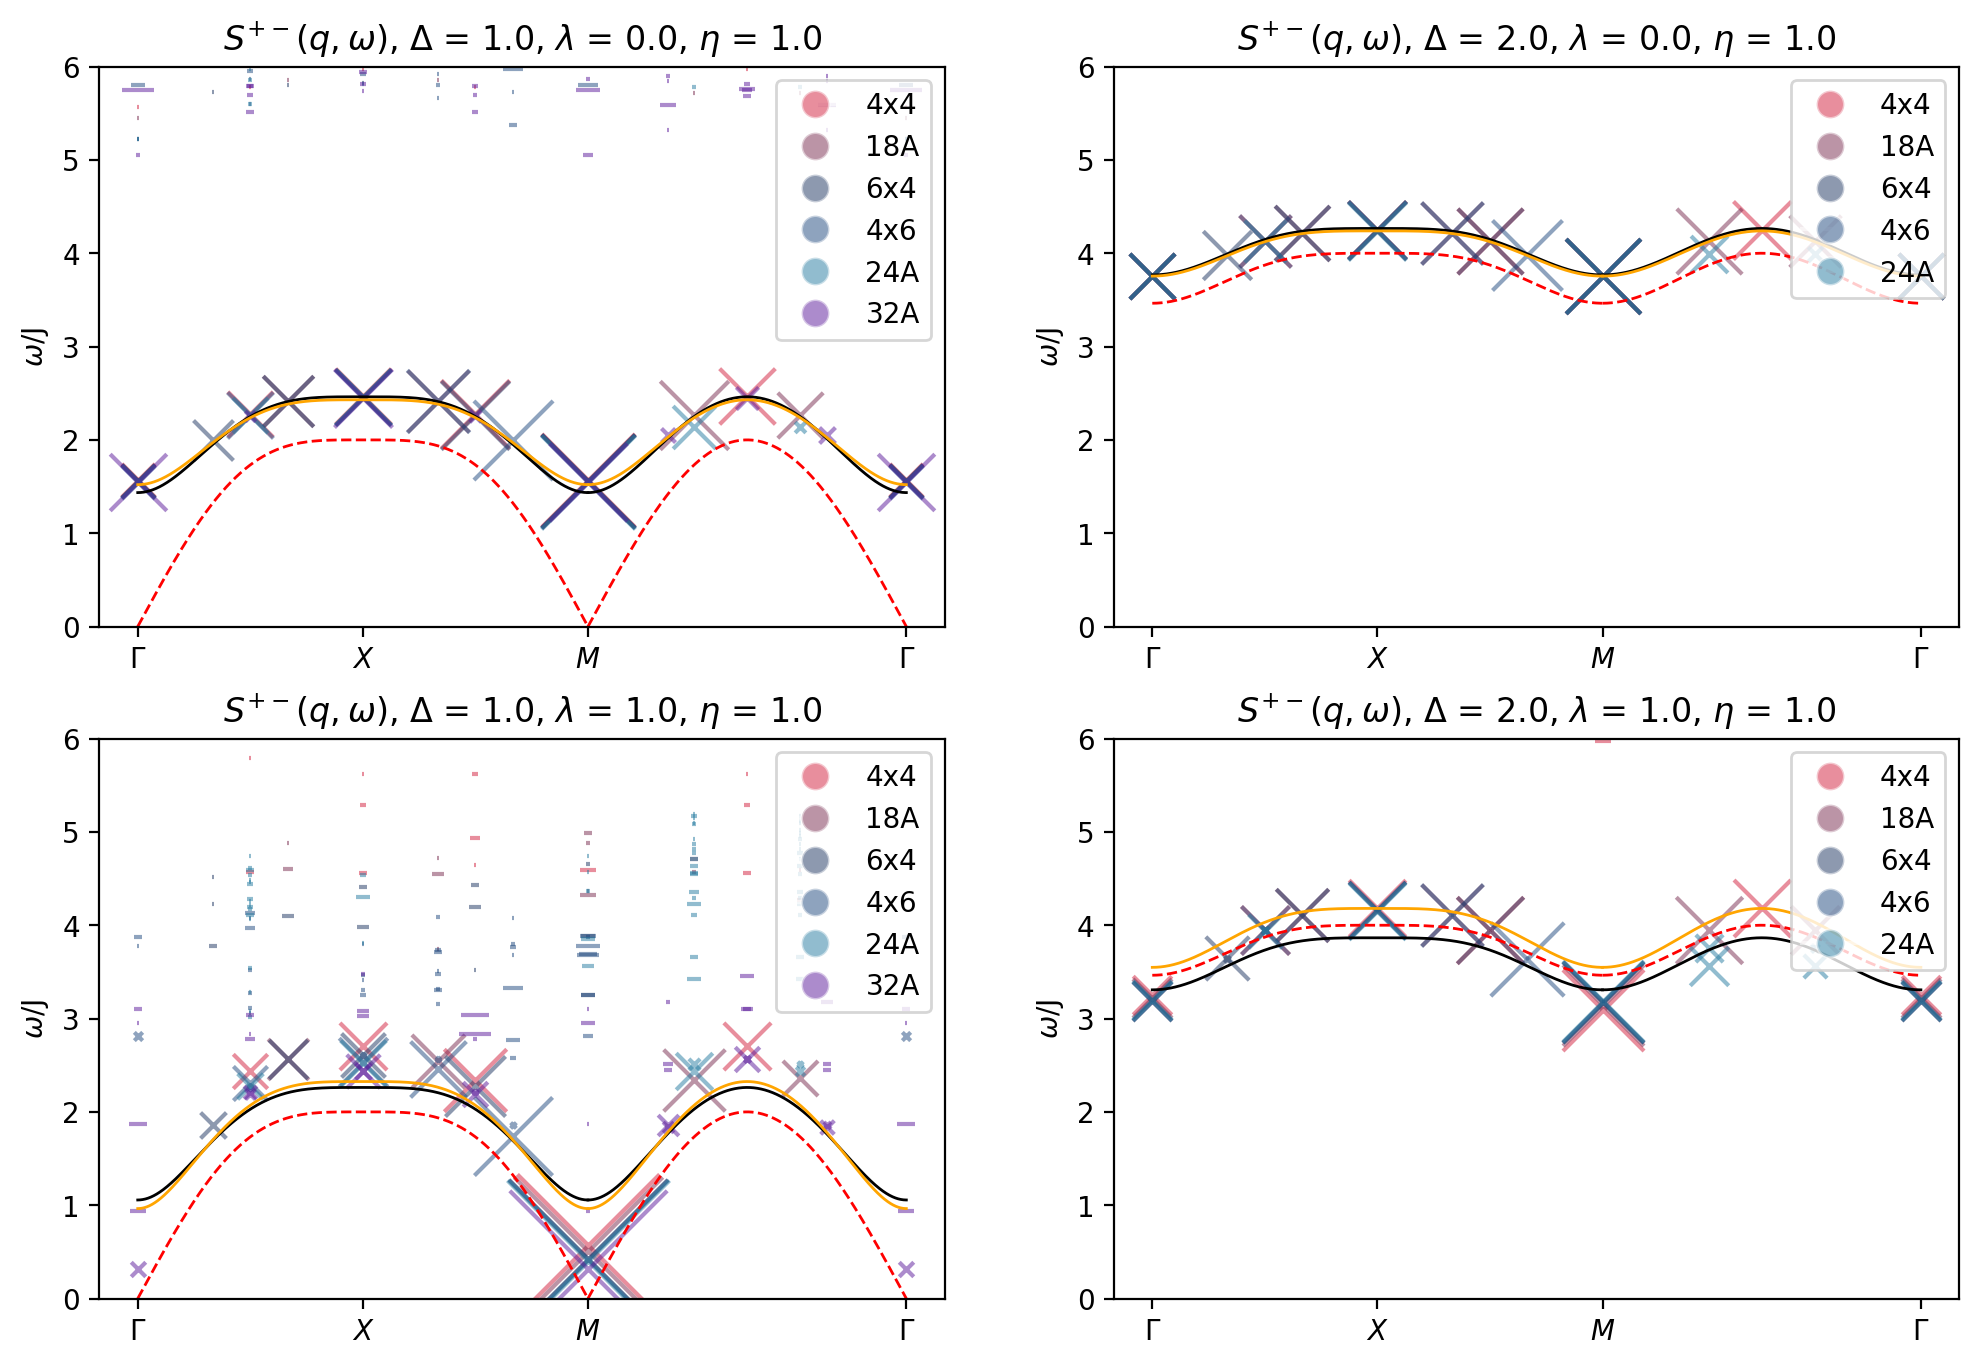

In [12]:
fig = plt.figure(figsize = (12, 8), dpi = 200)

#plt.title(r'HCB to B mean-field')

plt.subplot(2, 2, 1)
find_function_lamb(1., 0., 0.46175418/2/1.)
plot_hcb_b_mf(1.21483*2, 2*0.94761, c = 'orange', ls = '-')
plot_LSW(1., 'red', '--')

plt.subplot(2, 2, 2)
find_function_lamb(2., 0., 0.53066/4) #0.009758864997001914
plot_hcb_b_mf(2.11961*2, 2*0.98403, c = 'orange', ls = '-')
plot_LSW(2., 'red', '--')

plt.subplot(2, 2, 3)
find_function_lamb(1., 1., 0.46175418/2/1.)
plot_hcb_b_mf(1.16255*2, 2*1.05791, c = 'orange', ls = '-')
plot_LSW(1., 'red', '--')

plt.subplot(2, 2, 4)
find_function_lamb(2., 1., 0.53066/4) #0.009758864997001914
plot_hcb_b_mf(2.09001*2, 1.10453*2, c = 'orange', ls = '-')
plot_LSW(2., 'red', '--')

plt.show()

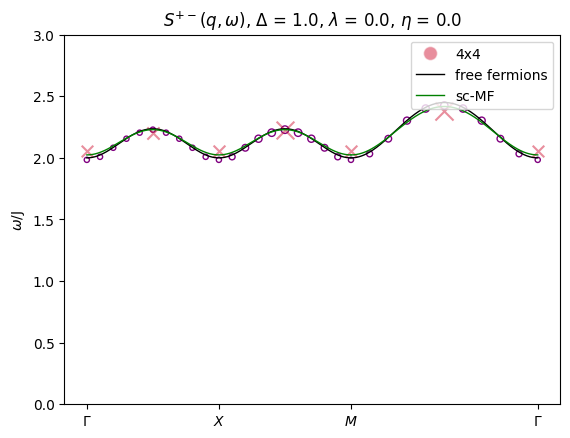

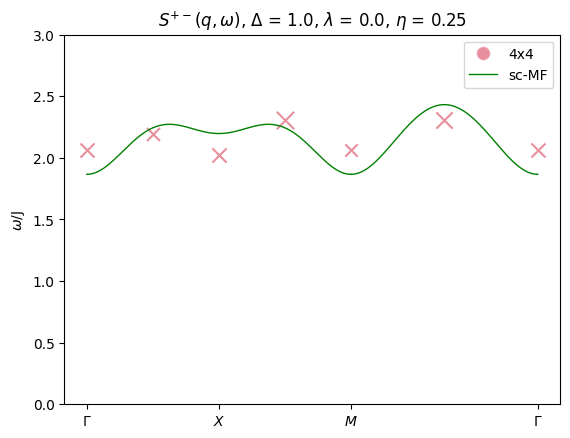

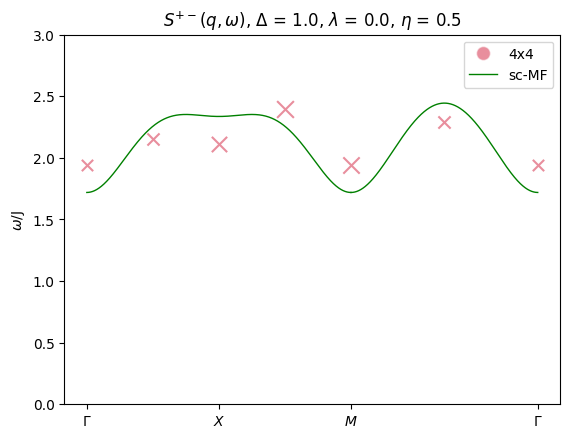

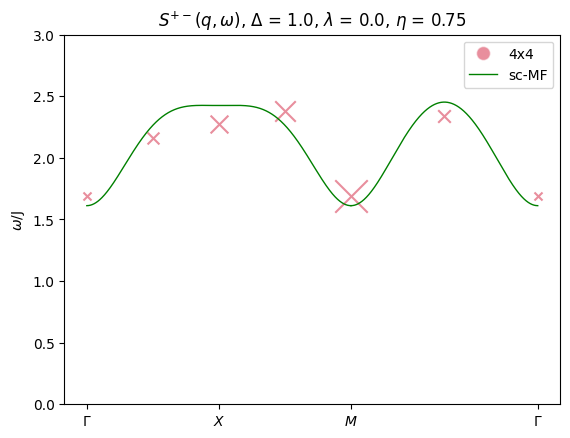

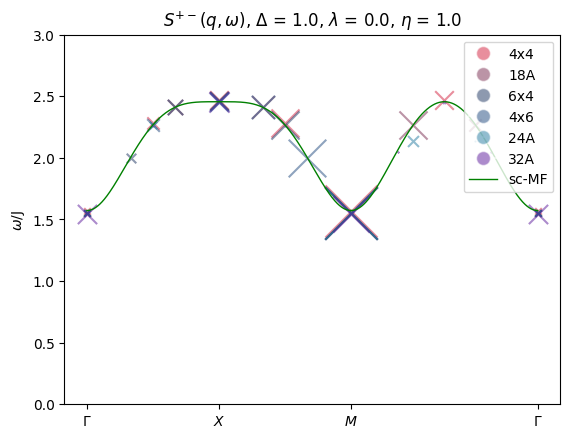

In [13]:
plot_all_for_var(lamb =0., eta = .0, ylim = 3, show = False)
plt.show()

plot_all_for_var(lamb =0., eta = .25, ylim = 3, show = False)
plt.show()

plot_all_for_var(lamb =0., eta = .5, ylim = 3, show = False)
plt.show()

plot_all_for_var(lamb =0., eta = .75, ylim = 3, show = False)
plt.show()

plot_all_for_var(lamb =0., eta = 1., ylim = 3, show = False)
plt.show()